In [1]:
import geokit as gk
import numpy as np
from os.path import join, isdir
from os import mkdir
from multiprocessing import Pool
from datetime import datetime as dt
from collections import namedtuple, OrderedDict
from json import dumps
from pathlib import Path
import matplotlib.pyplot as plt
import os

---

### run use priors

In [ ]:
# test_ExclusionCalculator_excludePrior() funktioniert - das excludieren von priors funktioniert -> es sind nur keine hinterlegt
priorSample = gl._test_data_["roads_prior_clip.tif"]
p = PriorSource(priorSample)    #loads prior dataset (tif file) # aachen roads


ec = gl.ExclusionCalculator(aachenShape)
ec.excludePrior(pr, value=(400, None))      #prior excludieren mit em wert 400?

___

In [7]:
#check values tif file
test = gk.raster.loadRaster("/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/input/clc-aachen_clipped.tif")
arr = gk.raster.extractMatrix(test)

## shape to raster ##

In [36]:
reg = gk.RegionMask.load("/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/input/Natura2000_aachenClipped.shp", limitOne=False)
example_data = reg.mask.astype(int)  
test =gk.raster.createRaster(data=example_data, output="/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/input/Natura2000_raster.tif", bounds=reg.extent.xyXY, srs=reg.srs)

/fast/home/l-madeisky/.conda/envs/glaes/lib/python3.10/site-packages/geokit/core/srs.py:283: DeprecationWarning: SRSCOMMON.europe_m is deprecated and will be removed in a future release.             use SRSCOMMON.europe_laea instead.
  warnings.warn(
/fast/home/l-madeisky/.conda/envs/glaes/lib/python3.10/site-packages/geokit/core/srs.py:283: DeprecationWarning: SRSCOMMON.europe_m is deprecated and will be removed in a future release.             use SRSCOMMON.europe_laea instead.
  warnings.warn(
/fast/home/l-madeisky/.conda/envs/glaes/lib/python3.10/site-packages/geokit/core/srs.py:283: DeprecationWarning: SRSCOMMON.europe_m is deprecated and will be removed in a future release.             use SRSCOMMON.europe_laea instead.
  warnings.warn(
/fast/home/l-madeisky/.conda/envs/glaes/lib/python3.10/site-packages/geokit/core/srs.py:283: DeprecationWarning: SRSCOMMON.europe_m is deprecated and will be removed in a future release.             use SRSCOMMON.europe_laea instead.
  warnings.wa

## raster to shape?

In [40]:
test = gk.raster.loadRaster("/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/input/Natura2000_raster.tif")
raster_matrix = gk.raster.extractMatrix(test)

In [65]:
ras_boolean = gk.raster.createRasterLike(source=test, data=raster_matrix == 1, noData=0)
polygonized_geoms = gk.raster.polygonizeRaster(ras_boolean)
gk.vector.createVector(polygonized_geoms, output="/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/input/natura_xxx.shp")

'/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/input/natura_xxx.shp'

In [68]:
reg_1 = gk.RegionMask.load("/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/input/Natura2000_aachenClipped.shp", limitOne=False)

/fast/home/l-madeisky/.conda/envs/glaes/lib/python3.10/site-packages/geokit/core/srs.py:283: DeprecationWarning: SRSCOMMON.europe_m is deprecated and will be removed in a future release.             use SRSCOMMON.europe_laea instead.
  warnings.warn(
/fast/home/l-madeisky/.conda/envs/glaes/lib/python3.10/site-packages/geokit/core/srs.py:283: DeprecationWarning: SRSCOMMON.europe_m is deprecated and will be removed in a future release.             use SRSCOMMON.europe_laea instead.
  warnings.warn(
/fast/home/l-madeisky/.conda/envs/glaes/lib/python3.10/site-packages/geokit/core/srs.py:283: DeprecationWarning: SRSCOMMON.europe_m is deprecated and will be removed in a future release.             use SRSCOMMON.europe_laea instead.
  warnings.warn(
/fast/home/l-madeisky/.conda/envs/glaes/lib/python3.10/site-packages/geokit/core/srs.py:283: DeprecationWarning: SRSCOMMON.europe_m is deprecated and will be removed in a future release.             use SRSCOMMON.europe_laea instead.
  warnings.wa

In [69]:
reg = gk.RegionMask.load("/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/input/natura_xxx.shp", limitOne=False)

/fast/home/l-madeisky/.conda/envs/glaes/lib/python3.10/site-packages/geokit/core/srs.py:283: DeprecationWarning: SRSCOMMON.europe_m is deprecated and will be removed in a future release.             use SRSCOMMON.europe_laea instead.
  warnings.warn(
/fast/home/l-madeisky/.conda/envs/glaes/lib/python3.10/site-packages/geokit/core/srs.py:283: DeprecationWarning: SRSCOMMON.europe_m is deprecated and will be removed in a future release.             use SRSCOMMON.europe_laea instead.
  warnings.warn(
/fast/home/l-madeisky/.conda/envs/glaes/lib/python3.10/site-packages/geokit/core/srs.py:283: DeprecationWarning: SRSCOMMON.europe_m is deprecated and will be removed in a future release.             use SRSCOMMON.europe_laea instead.
  warnings.warn(
/fast/home/l-madeisky/.conda/envs/glaes/lib/python3.10/site-packages/geokit/core/srs.py:283: DeprecationWarning: SRSCOMMON.europe_m is deprecated and will be removed in a future release.             use SRSCOMMON.europe_laea instead.
  warnings.wa

In [73]:
raster_1 = gk.raster.loadRaster("/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/input/Natura2000_raster.tif")
raster_matrix = gk.raster.extractMatrix(raster_1)
ras_boolean = gk.raster.createRasterLike(source=raster_1, data=raster_matrix == 1, noData=0)
vector_2 = gk.raster.polygonizeRaster(ras_boolean)
#vector = gk.vector.createVector(vector_2)
reg_1 = gk.RegionMask.load(vector_2)

GeoKitRegionMaskError: Could not understand region input

In [9]:
# Print min, max, mean
print("Min:", np.min(arr))
print("Max:", np.max(arr))
print("Mean:", np.mean(arr))

Min: 1
Max: 41
Mean: 16.140258473667547


### indicate values

Memory useage during calc: 168.37109375 MB


AxHands(ax=<Axes: >, handles=<matplotlib.image.AxesImage object at 0x7fe7aa251c00>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fe7aa214f10>)

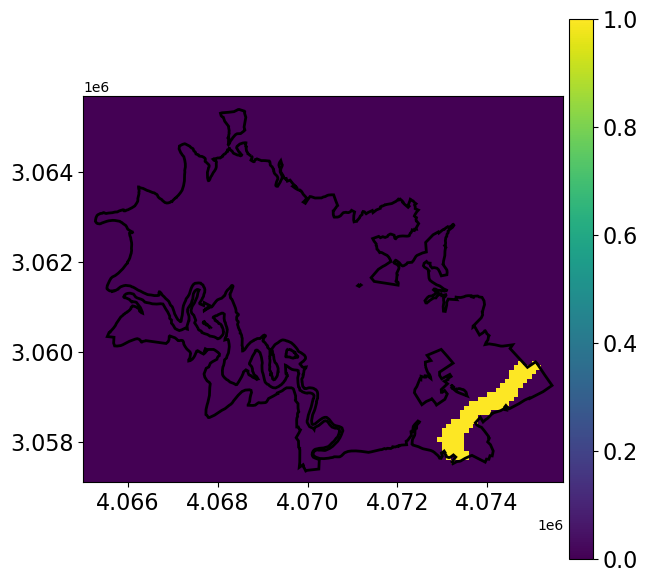

In [18]:
matrix = reg.indicateValues(
    source=tif_file_elevation,
    value=(0, 3)) > 0.5

reg.drawImage(matrix, figsize=(6, 6))

# plot

In [45]:
reg = gk.RegionMask.load(region="/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/input/Natura2000_aachenClipped.shp", where="SITENAME='Kermeter'", padExtent=1000) 

/fast/home/l-madeisky/.conda/envs/glaes/lib/python3.10/site-packages/geokit/core/srs.py:283: DeprecationWarning: SRSCOMMON.europe_m is deprecated and will be removed in a future release.             use SRSCOMMON.europe_laea instead.
  warnings.warn(
/fast/home/l-madeisky/.conda/envs/glaes/lib/python3.10/site-packages/geokit/core/srs.py:283: DeprecationWarning: SRSCOMMON.europe_m is deprecated and will be removed in a future release.             use SRSCOMMON.europe_laea instead.
  warnings.warn(
/fast/home/l-madeisky/.conda/envs/glaes/lib/python3.10/site-packages/geokit/core/srs.py:283: DeprecationWarning: SRSCOMMON.europe_m is deprecated and will be removed in a future release.             use SRSCOMMON.europe_laea instead.
  warnings.warn(
/fast/home/l-madeisky/.conda/envs/glaes/lib/python3.10/site-packages/geokit/core/srs.py:283: DeprecationWarning: SRSCOMMON.europe_m is deprecated and will be removed in a future release.             use SRSCOMMON.europe_laea instead.
  warnings.wa

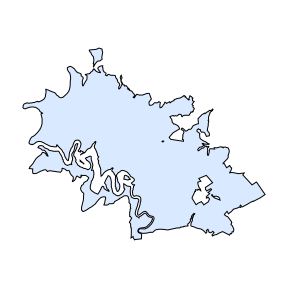

In [46]:
reg

In [47]:
example_data = np.ones_like(reg.mask)
reg.createRaster(data=example_data, output="/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/output/agriculture_proximity/region_of_interest.tif")

'/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/output/agriculture_proximity/region_of_interest.tif'

### from matrix

In [ ]:
region_df_clipped = gk.geom.polygonizeMatrix(matrix, bounds=reg.extent.xyXY, srs=reg.srs)
gk.geom.drawGeoms(region_df_clipped, figsize=(6, 6))

AxHands(ax=<Axes: >, handles=<matplotlib.image.AxesImage object at 0x7f57cfc5e500>, cbar=<matplotlib.colorbar.Colorbar object at 0x7f57cf55a230>)

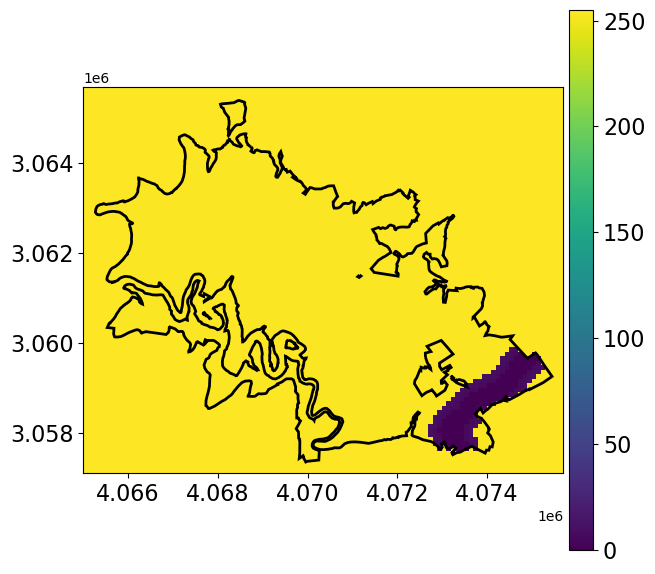

In [ ]:
### regionmask
reg.drawImage(result, figsize=(6, 6))

### raster

AxHands(ax=<Axes: >, handles=<matplotlib.image.AxesImage object at 0x7f18733ca650>, cbar=<matplotlib.colorbar.Colorbar object at 0x7f18733cb670>)

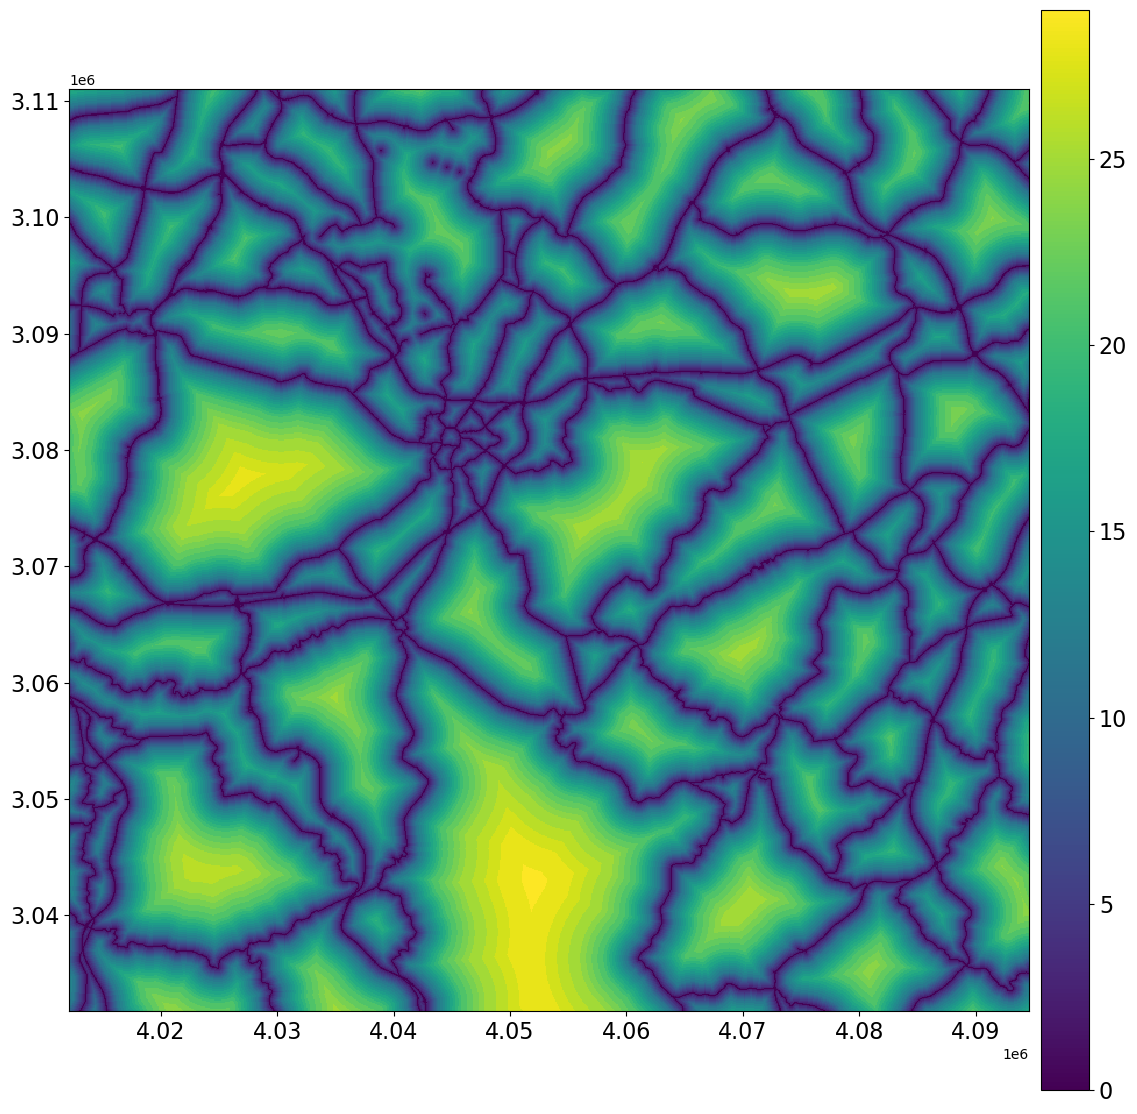

In [2]:
gk.drawRaster("/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/input/roads_prior_clip.tif")

AxHands(ax=<Axes: >, handles=<matplotlib.image.AxesImage object at 0x7f67e0431db0>, cbar=<matplotlib.colorbar.Colorbar object at 0x7f67e0432170>)

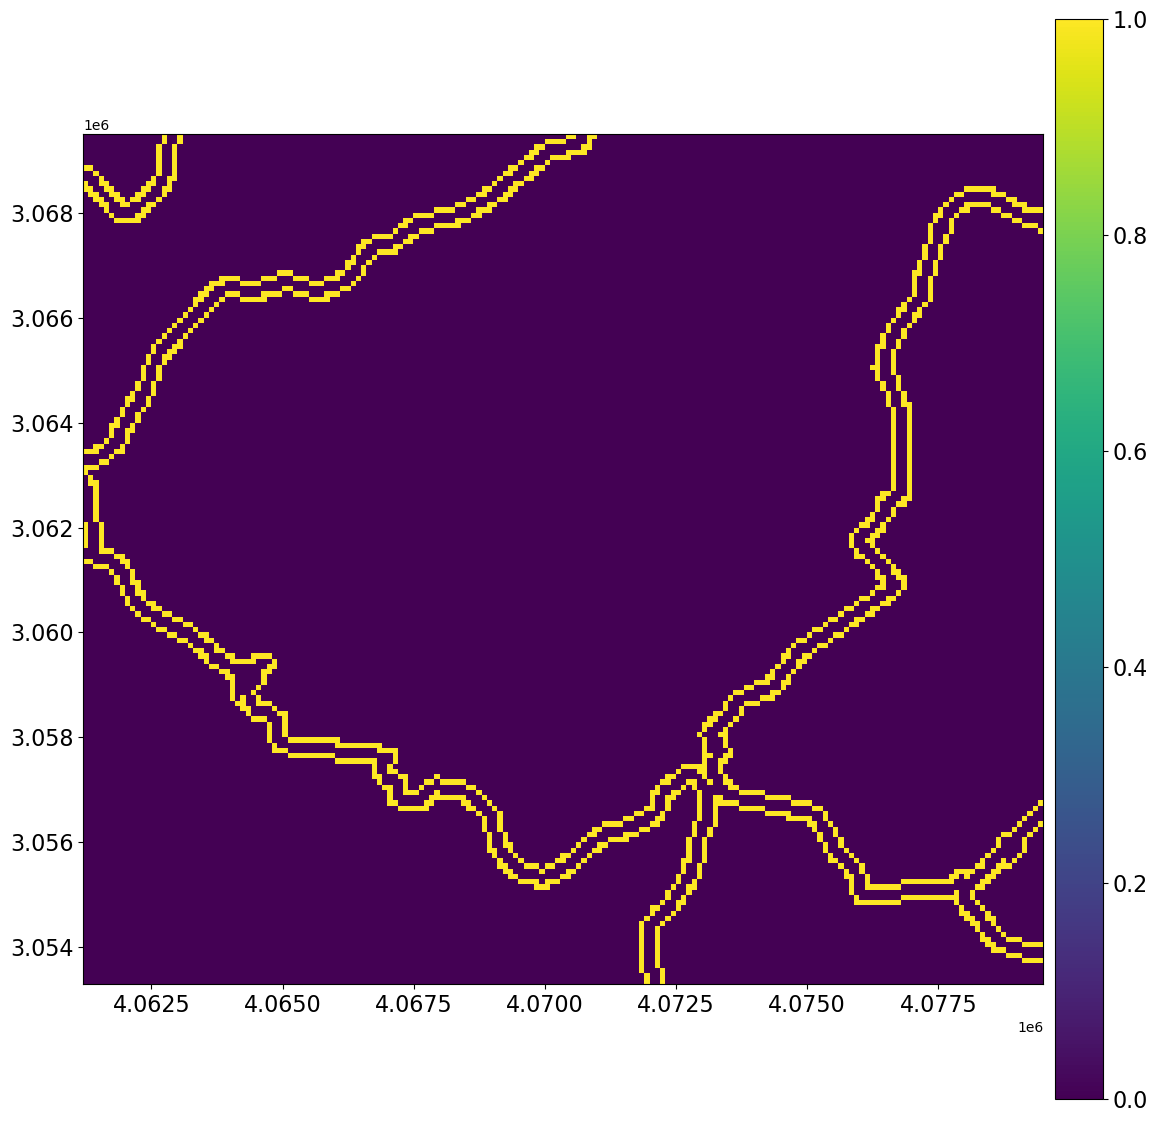

In [3]:
gk.drawRaster("/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/output/agriculture_proximity/feature_of_interest.tif")

AxHands(ax=<Axes: >, handles=<matplotlib.image.AxesImage object at 0x7f661a35d240>, cbar=<matplotlib.colorbar.Colorbar object at 0x7f661a3927d0>)

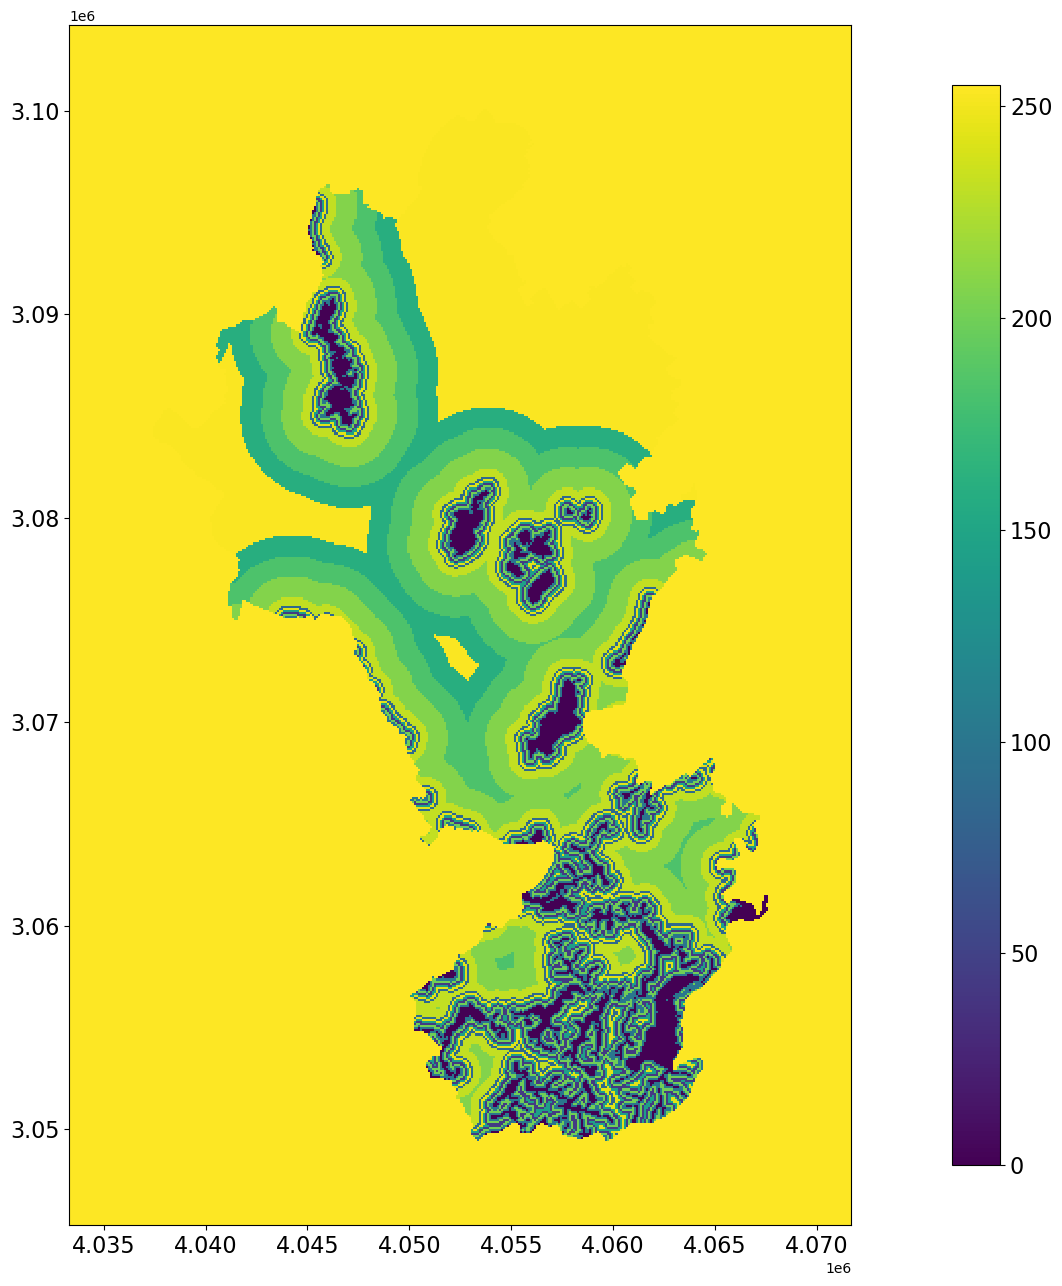

In [10]:
gk.drawRaster("/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/output/agriculture_proximity/agriculture_proximityby_shape.tif")

AxHands(ax=<Axes: >, handles=<matplotlib.image.AxesImage object at 0x7f661a5ed180>, cbar=<matplotlib.colorbar.Colorbar object at 0x7f661a5ed570>)

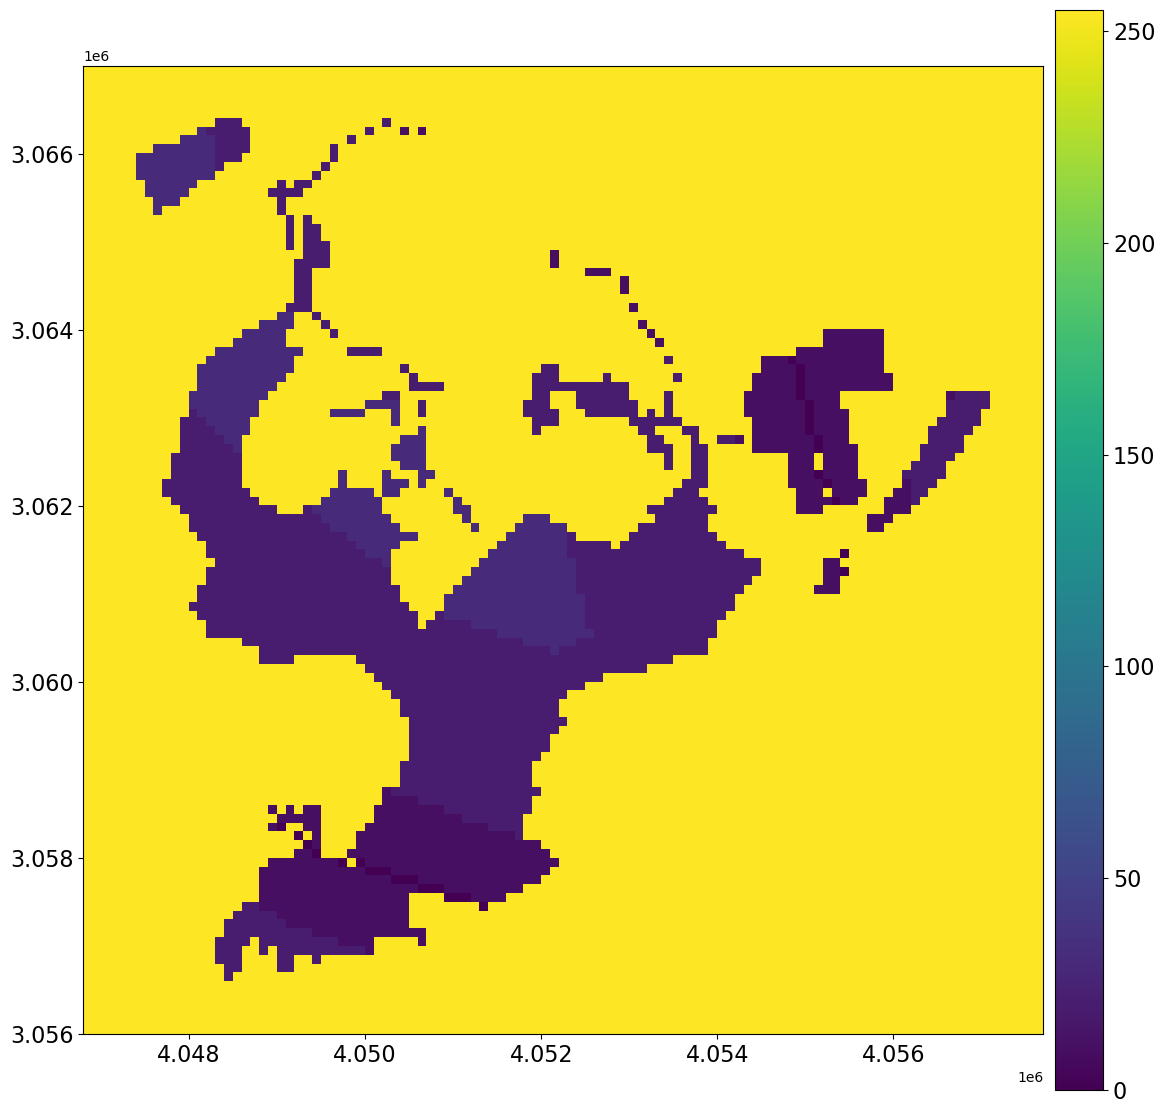

In [11]:
gk.drawRaster("/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/output/dni_threshold.tif")

### shape

AxHands(ax=<Axes: >, handles=0    PathPatch850((6.19844, 50.948) ...)
dtype: object, cbar=None)

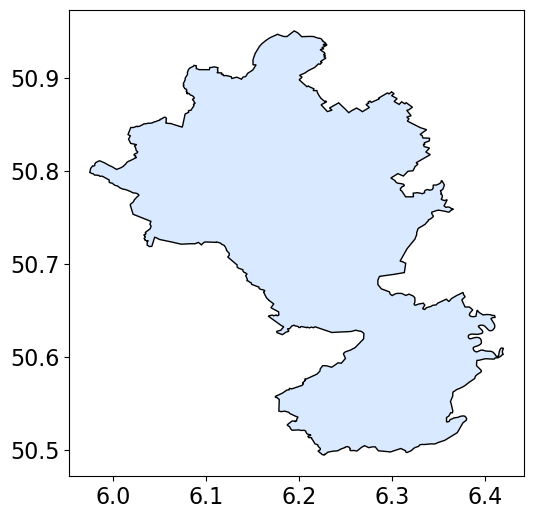

In [4]:
rails = gk.vector.extractFeatures("/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/input/Natura2000_aachenClipped.shp")
aachen = gk.vector.extractFeatures("/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/input/aachenShapefile.shp")
gk.drawGeoms(aachen,   figsize=(5, 5), srs=4326)

In [26]:
aachen= gk.vector.createVector(aachen, srs=4326)
rails= gk.vector.createVector(rails, srs=4326)

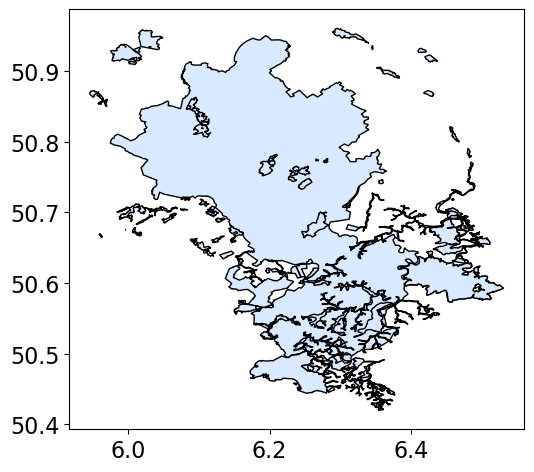

In [5]:
axh = gk.drawGeoms(aachen, figsize=(5, 5), srs=4326)
gk.drawGeoms(rails, ax=axh)
plt.show()